# Stacking Ensemble Model — CEFR Classification
Notebook ini melatih dan membandingkan SVM, Random Forest, XGBoost, serta Stacking Ensemble untuk klasifikasi level CEFR.

## 1. Import Library

In [1]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.impute import SimpleImputer

from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

# MODELS
from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

## 2. Load Dataset

In [2]:
# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv(
    'data/oxford_prosody_dataset.csv'
)

print("Shape Dataset :", df.shape)

df.head()

Shape Dataset : (10802, 24)


,word,cefr_level,speaker_id,scenario_id,pitch_mean,pitch_std,pitch_contour_slope,energy_rms,duration_seconds,speech_rate,...,pause_ratio,filler_words_rate,wpm_consistency,asr_confidence,semantic_relevance,whisper_feat_1,whisper_feat_2,whisper_feat_3,user_prior_score,prosody_similarity
0,beside,B2,SPK_116,interview,169.902061,27.389606,0.526225,0.093494,2.819739,3.730042,...,0.280799,0.130368,75.546917,0.867027,64.058871,4.645862,1.030129,-0.617425,74.029388,69.083244
1,beside,B2,SPK_027,casual_chat,159.440060,29.814136,0.460301,0.211605,2.650267,2.857137,...,0.268930,0.103543,67.919238,0.744258,67.427880,5.356399,2.614094,-0.996591,68.385447,74.082539
2,besides,B2,SPK_032,emergency,157.045591,29.558411,0.371714,0.099188,2.753135,3.020278,...,0.187943,0.094790,68.602293,0.829767,66.552441,4.372265,0.839443,1.600278,57.398946,80.611044
3,besides,B2,SPK_063,emergency,153.276901,26.382575,0.201269,0.142781,2.183486,3.510729,...,0.316551,0.090215,72.356833,0.795689,83.743854,4.066058,1.667308,-0.462622,65.914261,64.651960
4,absorb,B2,SPK_129,presentation,160.484550,22.728612,0.547665,0.081633,2.778153,3.706563,...,0.220770,0.079402,71.575648,0.913600,70.844463,3.567408,1.105058,-0.084095,51.040307,60.598457


## 3. Cek Nama Kolom

In [3]:
# =========================================================
# CEK NAMA KOLOM
# =========================================================

print(df.columns.tolist())

['word', 'cefr_level', 'speaker_id', 'scenario_id', 'pitch_mean', 'pitch_std', 'pitch_contour_slope', 'energy_rms', 'duration_seconds', 'speech_rate', 'response_time_ms', 'lexical_diversity', 'grammar_error_rate', 'pronunciation_accuracy', 'pause_ratio', 'filler_words_rate', 'wpm_consistency', 'asr_confidence', 'semantic_relevance', 'whisper_feat_1', 'whisper_feat_2', 'whisper_feat_3', 'user_prior_score', 'prosody_similarity']


## 4. Feature Engineering & Target

In [4]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

# Target
TARGET_COLUMN = 'cefr_level'

# Kolom yang dibuang
drop_columns = [
    'cefr_level',
    'word',
    'speaker_id',
    'scenario_id'
]

# Feature
X = df.drop(columns=drop_columns)

# Label
y = df[TARGET_COLUMN]

print("Shape Feature :", X.shape)

print("\nLabel CEFR :")
print(y.unique())

Shape Feature : (10802, 20)

Label CEFR :
<StringArray>
['B2', 'C1', 'A1', 'A2', 'B1', 'C2']
Length: 6, dtype: str


## 5. Label Encoding

In [5]:
# =========================================================
# LABEL ENCODING
# =========================================================

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Encoded Classes :")
print(le.classes_)

Encoded Classes :
['A1' 'A2' 'B1' 'B2' 'C1' 'C2']


## 6. Identifikasi Fitur Numerik

In [6]:
# =========================================================
# IDENTIFIKASI FITUR NUMERIK
# =========================================================

numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

print("Total Numeric Features :", len(numeric_features))

Total Numeric Features : 20


## 7. Preprocessing Pipeline

In [7]:
# =========================================================
# PREPROCESSING PIPELINE
# =========================================================

numeric_transformer = Pipeline(steps=[

    ('imputer',
     SimpleImputer(strategy='median')),

    ('scaler',
     StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        )
    ]
)

## 8. Train Test Split

In [8]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded
)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (8641, 20)
Test Shape  : (2161, 20)


## 9. Cross Validation

In [9]:
# =========================================================
# CROSS VALIDATION
# =========================================================

cv_strategy = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

## 10. SVM Pipeline

In [10]:
# =========================================================
# SVM PIPELINE
# =========================================================

svm_pipeline = ImbPipeline(steps=[

    ('preprocessor',
     preprocessor),

    ('feature_selection',
     SelectKBest(score_func=f_classif)),

    ('smote',
     SMOTE(random_state=42)),

    ('classifier',
     SVC(
         probability=True,
         random_state=42
     ))
])

svm_params = {

    'feature_selection__k':
        [5, 10, 15, 'all'],

    'classifier__C':
        [0.1, 1, 3, 10],

    'classifier__gamma':
        ['scale', 0.01, 0.001],

    'classifier__kernel':
        ['rbf']
}

## 11. Random Forest Pipeline

In [11]:
# =========================================================
# RANDOM FOREST PIPELINE
# =========================================================

rf_pipeline = ImbPipeline(steps=[

    ('preprocessor',
     preprocessor),

    ('smote',
     SMOTE(random_state=42)),

    ('classifier',
     RandomForestClassifier(
         random_state=42,
         class_weight='balanced',
         n_jobs=-1
     ))
])

rf_params = {

    'classifier__n_estimators':
        [200, 300],

    'classifier__max_depth':
        [10, 15, 20],

    'classifier__min_samples_split':
        [2, 5, 10],

    'classifier__min_samples_leaf':
        [1, 2, 4]
}

## 12. XGBoost Pipeline

In [12]:
# =========================================================
# XGBOOST PIPELINE
# =========================================================

xgb_pipeline = ImbPipeline(steps=[

    ('preprocessor',
     preprocessor),

    ('smote',
     SMOTE(random_state=42)),

    ('classifier',
     XGBClassifier(
         objective='multi:softprob',
         eval_metric='mlogloss',
         random_state=42,
         n_jobs=-1
     ))
])

xgb_params = {

    'classifier__n_estimators':
        [200, 300],

    'classifier__max_depth':
        [4, 6, 8],

    'classifier__learning_rate':
        [0.01, 0.03, 0.1],

    'classifier__subsample':
        [0.8, 1.0],

    'classifier__colsample_bytree':
        [0.8, 1.0]
}

## 13. Hyperparameter Tuning — SVM

In [13]:
# =========================================================
# HYPERPARAMETER TUNING — SVM
# =========================================================

print("Tuning SVM...")

svm_search = RandomizedSearchCV(

    estimator=svm_pipeline,

    param_distributions=svm_params,

    n_iter=10,

    scoring='f1_weighted',

    cv=cv_strategy,

    verbose=1,

    random_state=42,

    n_jobs=-1
)

svm_search.fit(X_train, y_train)

best_svm = svm_search.best_estimator_

print("\nBest SVM Params:")
print(svm_search.best_params_)

Tuning SVM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best SVM Params:
{'feature_selection__k': 'all', 'classifier__kernel': 'rbf', 'classifier__gamma': 0.01, 'classifier__C': 1}


## 14. Hyperparameter Tuning — Random Forest

In [14]:
# =========================================================
# HYPERPARAMETER TUNING — RANDOM FOREST
# =========================================================

print("Tuning Random Forest...")

rf_search = RandomizedSearchCV(

    estimator=rf_pipeline,

    param_distributions=rf_params,

    n_iter=10,

    scoring='f1_weighted',

    cv=cv_strategy,

    verbose=1,

    random_state=42,

    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("\nBest RF Params:")
print(rf_search.best_params_)

Tuning Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/macbookpro/Documents/project/Deep-Interaction-Analysis-Framework/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/macbookpro/Documents/project/Deep-Interaction-Analysis-Framework/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/macbookpro/Documents/project/Deep-Interaction-Analysis-Framework/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the 


Best RF Params:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 15}


## 15. Hyperparameter Tuning — XGBoost

In [15]:
# =========================================================
# HYPERPARAMETER TUNING — XGBOOST
# =========================================================

print("Tuning XGBoost...")

xgb_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=xgb_params,

    n_iter=10,

    scoring='f1_weighted',

    cv=cv_strategy,

    verbose=1,

    random_state=42,

    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("\nBest XGB Params:")
print(xgb_search.best_params_)

Tuning XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best XGB Params:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 1.0}


## 16. Evaluasi Model

In [16]:
# =========================================================
# EVALUASI MODEL
# =========================================================

models = {
    'SVM': best_svm,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

results = []

for name, model in models.items():

    print("\n========================")
    print(f"MODEL : {name}")
    print("========================")

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print("Accuracy :", accuracy)
    print("F1 Score :", f1)

    print("\nClassification Report :")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=le.classes_
        )
    )

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 Score': f1
    })


MODEL : SVM
Accuracy : 0.992133271633503
F1 Score : 0.9921244224651092

Classification Report :
              precision    recall  f1-score   support

          A1       0.99      1.00      1.00       329
          A2       1.00      0.98      0.99       320
          B1       0.99      1.00      0.99       263
          B2       0.99      1.00      0.99       529
          C1       1.00      0.98      0.99       520
          C2       0.99      1.00      0.99       200

    accuracy                           0.99      2161
   macro avg       0.99      0.99      0.99      2161
weighted avg       0.99      0.99      0.99      2161


MODEL : Random Forest
Accuracy : 0.976399814900509
F1 Score : 0.9763711487939961

Classification Report :
              precision    recall  f1-score   support

          A1       0.98      0.98      0.98       329
          A2       0.97      0.96      0.97       320
          B1       0.97      0.99      0.98       263
          B2       0.98      0.99   

## 17. Confusion Matrix

<Figure size 800x600 with 0 Axes>

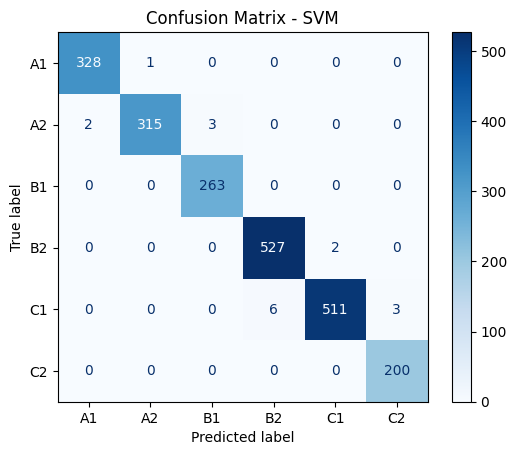

<Figure size 800x600 with 0 Axes>

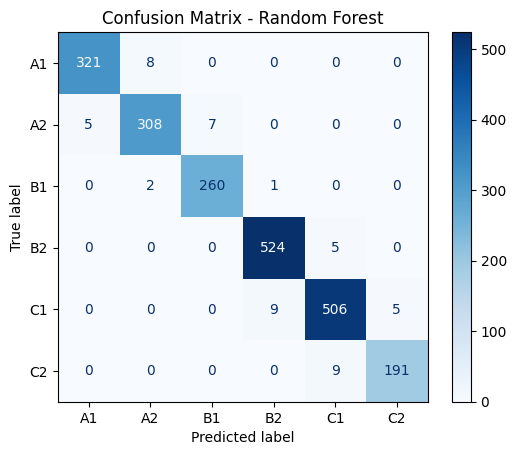

<Figure size 800x600 with 0 Axes>

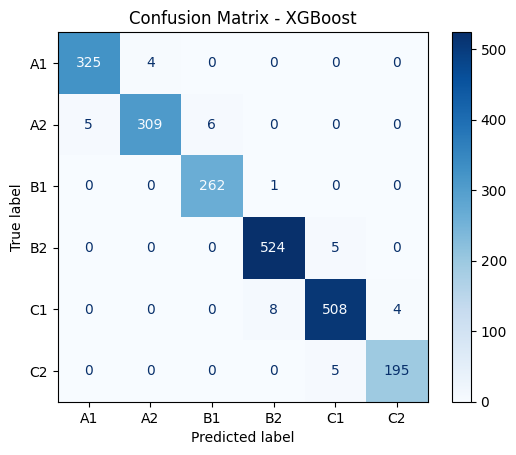

In [17]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

for name, model in models.items():

    y_pred = model.predict(X_test)

    plt.figure(figsize=(8,6))

    ConfusionMatrixDisplay.from_predictions(

        y_test,

        y_pred,

        display_labels=le.classes_,

        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')

    plt.show()

## 18. Hasil Perbandingan Model

In [18]:
# =========================================================
# HASIL PERBANDINGAN MODEL
# =========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)

print(results_df)

           Model  Accuracy  F1 Score
0            SVM  0.992133  0.992124
2        XGBoost  0.982416  0.982393
1  Random Forest  0.976400  0.976371


## 19. Stacking Ensemble (Advanced)

In [19]:
# =========================================================
# STACKING ENSEMBLE
# =========================================================

stacking_model = StackingClassifier(

    estimators=[
        ('svm', best_svm),
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],

    final_estimator=LogisticRegression(),

    n_jobs=-1
)

print("Training Stacking Ensemble...")

stacking_model.fit(X_train, y_train)

y_pred_stack = stacking_model.predict(X_test)

print("\n=== STACKING ENSEMBLE REPORT ===")

print(
    classification_report(
        y_test,
        y_pred_stack,
        target_names=le.classes_
    )
)

Training Stacking Ensemble...

=== STACKING ENSEMBLE REPORT ===
              precision    recall  f1-score   support

          A1       0.99      0.99      0.99       329
          A2       0.99      0.98      0.99       320
          B1       0.99      1.00      0.99       263
          B2       0.99      0.99      0.99       529
          C1       0.99      0.98      0.99       520
          C2       0.99      1.00      0.99       200

    accuracy                           0.99      2161
   macro avg       0.99      0.99      0.99      2161
weighted avg       0.99      0.99      0.99      2161



## 20. Final Confusion Matrix — Stacking

<Figure size 800x600 with 0 Axes>

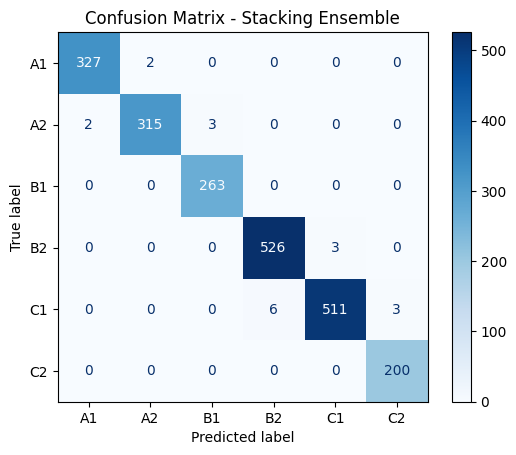

In [20]:
# =========================================================
# FINAL CONFUSION MATRIX STACKING
# =========================================================

plt.figure(figsize=(8,6))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred_stack,

    display_labels=le.classes_,

    cmap='Blues'
)

plt.title('Confusion Matrix - Stacking Ensemble')

plt.show()